In [1]:
#%% Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
from scipy.ndimage import gaussian_filter
import math
from PIL import Image
from matplotlib.ticker import MaxNLocator

from scipy.signal import welch
from scipy.optimize import curve_fit
import re
from scipy.signal import savgol_filter
from matplotlib.ticker import MaxNLocator
from matplotlib.patches import Circle
import matplotlib as mpl
from mpl_toolkits.mplot3d import Axes3D
from numba import njit, jit
from scipy import constants

In [2]:
# NN vectors
d1 = np.array([0, 1])
d2 = np.array([np.sqrt(3)/2, -1/2])
d3 = np.array([-np.sqrt(3)/2, -1/2])
delta = [d1, d2, d3]
delta = np.array(delta)

v1 = d2 - d3 
v2 = d3 - d1 
v3 = d1 - d2 
nn_delta = [v1, v2, v3]
nn_delta = np.array(nn_delta)

# Spin matrices
sx = np.array([[0.0 , 1.0] , [1.0 , 0.0]] , dtype = complex )
sy = np.array([[0.0 , -1.0j], [1.0j , 0.0]] , dtype = complex )
sz = np.array([[1.0 , 0.0] , [0.0 , -1.0]] , dtype = complex )
I2 = np.eye(2 , dtype = complex )
Sz4 = np.block([[ sz , np . zeros ((2 , 2) , dtype = complex )] , [ np . zeros ((2 , 2) , dtype = complex ) , sz ]])

# Primitive Lattice vectors
a1 = np.array ([np.sqrt(3) , 0.0])
a2 = np . array ([np.sqrt(3) / 2.0 , 3/2])

# Reciprocal space primitive vectors
area_real = np.cross(np.append(a1 , 0.0), np.append(a2, 0.0))[2]
b1 = 2.0 * np.pi * np.array([a2[1], -a2[0]]) / area_real
b2 = 2.0 * np.pi * np.array([-a1[1], a1[0]]) / area_real
BZ_AREA = abs(np.cross(np.append(b1 , 0.0), np.append(b2, 0.0))[2])

In [3]:
# Universal constants
hbar = constants.h/(2*np.pi)  # Reduced Planck's constant
mass = 9.1e-31                # Electron mass

## Band Structure

In [4]:
def kane_mele_hamiltonian(k, t, lso, lr, lv) :
    """Returns the energy bands, Hamiltonian matrix, and the derivatives of the Hamiltonian.
    k   : K-point at which energy is required
    t   : nearest-neighbour hopping term
    lso : intrinsic SOC term
    lv  : Mass term
    lr  : Rashba coupling term
    """
    k = np.array(k)    
    g = 0.0j
    R = np.zeros((2, 2), dtype = complex)
    for d in delta:
        phase = np.exp(1.0j * np.dot(k, d))
        g += phase
        R += 1.0j * lr * phase * (d[1] * sx - d[0] * sy) 
        
    dso = 0.0
    for b in nn_delta :
        dso += 2.0 * lso * np.sin(np . dot(k, b)) 

    H = np.zeros((4, 4) , dtype = complex)
    H[:2, :2] = lv * I2 + dso * sz
    H[2:, 2:] = -lv * I2 - dso * sz
    off = -t * g * I2 + R
    H[:2, 2:] = off
    H[2:, :2] = off.conj().T


    bands = np.linalg.eigvalsh(H)

    g = 0.0j
    dgx = 0.0j
    dgy = 0.0j
    R = np.zeros((2 , 2) , dtype = complex)
    dRdx = np.zeros((2 , 2) , dtype = complex)
    dRdy = np.zeros((2 , 2) , dtype = complex)
    for d in delta:
        phase = np.exp(1.0j * np . dot (k , d ))
        g += phase
        dgx += 1.0j * d [0] * phase
        dgy += 1.0j * d [1] * phase
        spin_mat = d [1] * sx - d [0] * sy
        R += 1.0j * lr * phase * spin_mat
        dRdx += 1.0j * lr * (1.0j * d [0]) * phase * spin_mat
        dRdy += 1.0j * lr * (1.0j * d [1]) * phase * spin_mat

    dso = 0.0
    ddsox = 0.0
    ddsoy = 0.0
    for b in nn_delta:
        arg = np.dot(k, b)
        dso += 2.0 * lso * np.sin(arg)
        ddsox += 2.0 * lso * b[0] * np.cos(arg)
        ddsoy += 2.0 * lso * b[1] * np.cos(arg)

    dHx = np.zeros((4, 4), dtype = complex)
    dHy = np.zeros((4, 4), dtype = complex)

    dHx[:2 , :2] = ddsox * sz
    dHx[2: , 2:] = - ddsox * sz
    dHy[:2 , :2] = ddsoy * sz
    dHy[2: , 2:] = - ddsoy * sz
    doffx = -t * dgx * I2 + dRdx
    doffy = -t * dgy * I2 + dRdy
    dHx[:2 , 2:] = doffx
    dHx[2: , :2] = doffx.conj().T
    dHy[:2 , 2:] = doffy
    dHy[2: , :2] = doffy.conj().T

    return bands, H, dHx, dHy



In [5]:
G_pt = np.array([0, 0])
K_pt = np.array([2 * np.pi / (3 * np.sqrt(3)), 2 * np.pi / 3])
Kp_pt = np.array([-2 * np.pi / (3 * np.sqrt(3)), 2 * np.pi / 3])
M_pt = np.array([0, 2 * np.pi / 3])
n_points = 100

def generate_path(p1, p2, n):
    return np.linspace(p1, p2, n)

path1 = generate_path(G_pt, K_pt, n_points)
path2 = generate_path(K_pt, M_pt, n_points)
path3 = generate_path(M_pt, Kp_pt, n_points)
path4 = generate_path(Kp_pt, G_pt, n_points)

full_path = np.vstack([path1, path2, path3, path4])

kx = full_path[:, 0]
ky = full_path[:, 1]

distances = np.sqrt(np.diff(kx)**2 + np.diff(ky)**2)
x_axis = np.concatenate(([0], np.cumsum(distances)))

<>:20: SyntaxWarning: invalid escape sequence '\G'
<>:20: SyntaxWarning: invalid escape sequence '\G'
<>:23: SyntaxWarning: invalid escape sequence '\l'
<>:23: SyntaxWarning: invalid escape sequence '\l'
<>:23: SyntaxWarning: invalid escape sequence '\l'
<>:20: SyntaxWarning: invalid escape sequence '\G'
<>:20: SyntaxWarning: invalid escape sequence '\G'
<>:23: SyntaxWarning: invalid escape sequence '\l'
<>:23: SyntaxWarning: invalid escape sequence '\l'
<>:23: SyntaxWarning: invalid escape sequence '\l'
C:\Users\ASUS\AppData\Local\Temp\ipykernel_26380\2694915564.py:20: SyntaxWarning: invalid escape sequence '\G'
  plt.xticks([x_axis[0], x_axis[n_points], x_axis[2*n_points], x_axis[3*n_points], x_axis[-1]], ['$\Gamma$', '$K$', '$M$', '$K\'$', '$\Gamma$'],fontsize=20)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_26380\2694915564.py:20: SyntaxWarning: invalid escape sequence '\G'
  plt.xticks([x_axis[0], x_axis[n_points], x_axis[2*n_points], x_axis[3*n_points], x_axis[-1]], ['$\Gamma$', '$

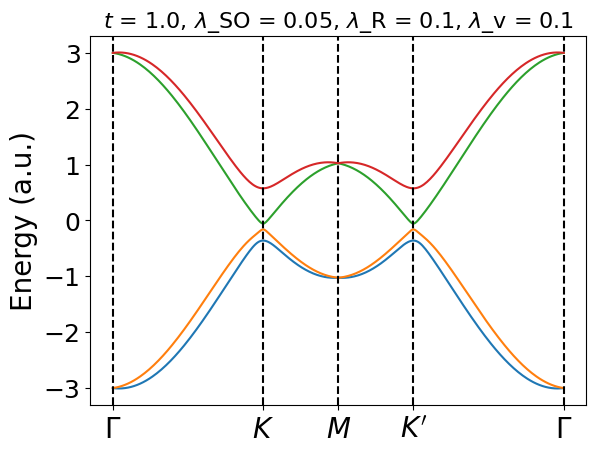

In [6]:
all_bands = []
t = 1.0
lso=0.05
lr= 0.1
lv= 0.1
for i in range(len(kx)):
    bands,_,_,_ = kane_mele_hamiltonian([kx[i], ky[i]], t=t, lso=lso, lr=lr, lv=lv)
    all_bands.append(bands)

all_bands = np.array(all_bands) 

for i in range(4):
    plt.plot(x_axis, all_bands[:, i], label=f'Band {i+1}')

plt.axvline(x=x_axis[0], color='k', linestyle='--')
plt.axvline(x=x_axis[n_points], color='k', linestyle='--')
plt.axvline(x=x_axis[2*n_points], color='k', linestyle='--') 
plt.axvline(x=x_axis[3*n_points], color='k', linestyle='--') 
plt.axvline(x=x_axis[-1], color='k', linestyle='--')
plt.xticks([x_axis[0], x_axis[n_points], x_axis[2*n_points], x_axis[3*n_points], x_axis[-1]], ['$\Gamma$', '$K$', '$M$', '$K\'$', '$\Gamma$'],fontsize=20)
plt.yticks(fontsize=18)
plt.ylabel("Energy (a.u.)", size = 20)
plt.title(f'$t$ = {t}, $\lambda$_SO = {lso}, $\lambda$_R = {lr}, $\lambda$_v = {lv}', size = 16)
plt.show()

## Spin-Hall Effect

In [7]:
def get_spin_hall(t, lso, lr, lv, nk):
    """Returns spin-Hall conductivity calculated by Kubo formula.
    t   : nearest-neighbour hopping term
    lso : intrinsic SOC term
    lv  : Mass term
    lr  : Rashba coupling term
    """
    total = 0.0
    for iu in range(nk):
        u = (iu + 0.5) / nk
        for iv in range(nk):
            v = (iv + 0.5) / nk
            k = u * b1 + v * b2
            _, H, dHx, dHy = kane_mele_hamiltonian([k[0], k[1]], t=t, lso=lso, lv=lv, lr=lr)
            evals, evecs = np.linalg.eigh(H)
            vx = dHx
            vy = dHy
            Jsx_code = 0.5 * (Sz4 @ vx + vx @ Sz4)  # uses sigma_z, not S_z = sigma_z/2
            for n in (0, 1):
                an = evecs[:, n]
                for m in (2, 3):
                    am = evecs[:, m]
                    denom = (evals[m] - evals[n]) ** 2
                    total += -2.0 * np.imag(np.vdot(an, Jsx_code @ am) * np.vdot(am, vy @ an)) / denom
    total *= BZ_AREA / (nk * nk) / (2.0 * np.pi) ** 2
    sigma_in_e_over_2pi = 0.5 * total * (2.0 * np.pi)

    return float(np.real_if_close(sigma_in_e_over_2pi))


<>:14: SyntaxWarning: invalid escape sequence '\l'
<>:22: SyntaxWarning: invalid escape sequence '\l'
<>:14: SyntaxWarning: invalid escape sequence '\l'
<>:22: SyntaxWarning: invalid escape sequence '\l'
C:\Users\ASUS\AppData\Local\Temp\ipykernel_26380\2380798743.py:14: SyntaxWarning: invalid escape sequence '\l'
  plt.plot(lv_vals, np.abs(sigma_vals), label = f'$\lambda_R$ = {lr}')
C:\Users\ASUS\AppData\Local\Temp\ipykernel_26380\2380798743.py:22: SyntaxWarning: invalid escape sequence '\l'
  plt.plot(lv_vals, np.abs(sigma_vals), label = f'$\lambda_R$ = {lr}')


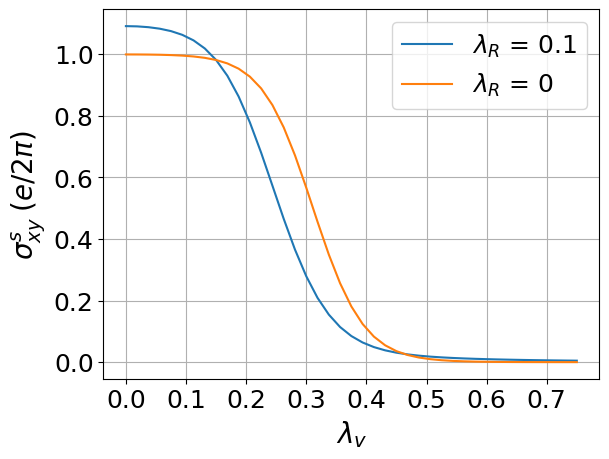

In [9]:
t = 1.0
lso = 0.06
nk = 21  # increase to get better accuracy
lv_vals = np.linspace(0, 0.75, 41)

plt.figure()

lr = 0.1
sigma_vals = []
for lv in lv_vals:
    sigma = get_spin_hall(t=t, lso=lso, lr=lr, lv=lv, nk=nk)
    sigma_vals.append(sigma)
sigma_vals = np.array(sigma_vals)
plt.plot(lv_vals, np.abs(sigma_vals), label = f'$\lambda_R$ = {lr}')

lr = 0
sigma_vals = []
for lv in lv_vals:
    sigma = get_spin_hall(t=t, lso=lso, lr=lr, lv=lv, nk=nk)
    sigma_vals.append(sigma)
sigma_vals = np.array(sigma_vals)
plt.plot(lv_vals, np.abs(sigma_vals), label = f'$\lambda_R$ = {lr}')


plt.xlabel(r"$\lambda_v$", size = 20)
plt.ylabel(r"$\sigma_{xy}^s \; (e/2\pi)$", size = 20)
plt.yticks(fontsize=18)
plt.xticks(fontsize=18)
plt.grid()
plt.legend(fontsize = 18)
plt.show()

## Topological Phase Diagram

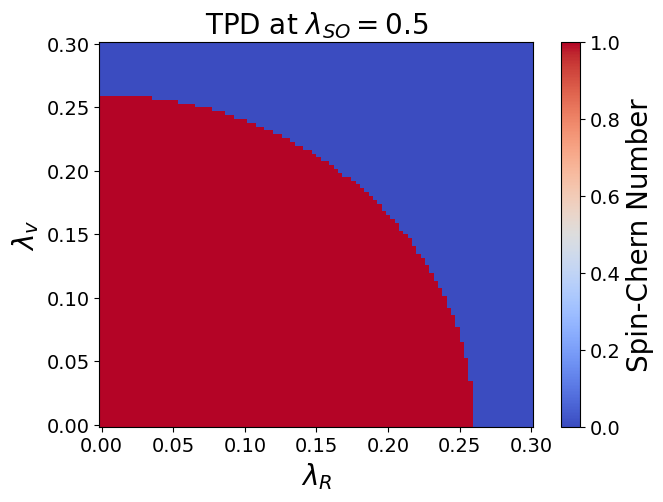

In [19]:
Sx = np.kron(I2, sx); Sy = np.kron(I2, sy); Sz = np.kron(I2, sz)

N = 100
lv_axis = np.linspace(0, 0.3, N)
lr_axis = np.linspace(0, 0.3, N)
LSO = 0.05
cs_grid = np.zeros((N, N))

for i, lv in enumerate(lv_axis):
    for j, lr in enumerate(lr_axis):
        # Here, the analytical phase boundary derived from the KM gap closing is used
        if (lv**2 + lr**2) < (3 * np.sqrt(3) * LSO)**2:
            cs_grid[i, j] = 1 # QSH/TI Phase
        else:
            cs_grid[i, j] = 0 # Trivial Phase

plt.figure(figsize=(7, 5))
plt.pcolormesh(lr_axis, lv_axis, cs_grid, cmap='coolwarm', shading='auto')
cbar = plt.colorbar(label='Spin-Chern Number $C_s$')
plt.xlabel(r'$\lambda_R$', size = 20)
plt.ylabel(r'$\lambda_v$', size = 20)
plt.title(r'TPD at $\lambda_{SO} = 0.5$', size = 20)
plt.xticks(size = 14)
plt.yticks(size = 14)
cbar.ax.tick_params(labelsize=14)
cbar.set_label('Spin-Chern Number', size=20)
plt.show()

Last question answered completely in report.